Bayesian Convolutional Neural Network untuk Deteksi Diabetic Retinopathy
Dataset: Diabetic Retinopathy 224x224 (2019) from Kaggle
Framework: **PyTorch** dengan Monte Carlo Dropout

---
**Catatan konversi (TensorFlow/Keras → PyTorch):**
- `ImageDataGenerator` → `Dataset` + `DataLoader` custom (`RetinopathyDataset`) dengan `torchvision.transforms`.
- `DenseNet121` Keras (ImageNet) → `torchvision.models.densenet121` (ImageNet) dibungkus dalam `nn.Module` custom (`BayesianDenseNet121`), dengan head Dense+MC Dropout yang sama persis strukturnya.
- `model.fit(...)` (2 tahap: head warm-up lalu fine-tune semua layer) → training loop manual PyTorch, dengan `EarlyStopping` + `ReduceLROnPlateau` + checkpoint terbaik yang diimplementasikan sendiri (setara `callbacks` Keras).
- `plot_model` → `torchinfo.summary` (ringkasan arsitektur berbasis teks).
- MC Dropout saat inferensi: pada Keras dilakukan dengan mengecek substring `"dropout"` pada nama layer; pada PyTorch dilakukan lebih aman dengan `isinstance(module, nn.Dropout)`, sementara seluruh `BatchNorm` (baik di backbone maupun `bn_1`) tetap di mode `eval()` — persis niat kode aslinya.
- Model disimpan sebagai `state_dict` (`.pth`), bukan file `.h5` utuh — ini cara standar & lebih portabel di PyTorch.
- **Perbaikan/tambahan:** normalisasi ImageNet (mean/std) pada gambar input (sebelumnya cuma `rescale=1/255`), seeding untuk reproducibility, `DataLoader` dengan `num_workers`/`pin_memory` untuk kecepatan, serta beberapa pengecekan defensif (verifikasi bobot pretrained, verifikasi arsitektur setelah load).
- Bagian yang murni pemrosesan data (download Kaggle, copy dari Drive, split train/val/test, class weights, evaluasi per-kelas) **tidak diubah** karena sudah framework-agnostic (numpy/pandas/sklearn).


In [1]:
#@title 1a. Install kagglehub, torchinfo & mount Google Drive
!pip install -q kagglehub torchinfo

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import os
import json
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ============================================================================
# Reproducibility (tidak ada di kode TensorFlow asli — ditambahkan)
# ============================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Menggunakan device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  GPU tidak terdeteksi — training akan sangat lambat di CPU.")
    print("   Di Colab: Runtime > Change runtime type > GPU (T4).")


✅ Menggunakan device: cuda
   GPU: Tesla T4


In [3]:
import kagglehub

aptos_path = kagglehub.dataset_download("sovitrath/diabetic-retinopathy-224x224-2019-data")
print("Path to dataset files:", aptos_path)

# struktur dataset ini: <aptos_path>/train.csv + <aptos_path>/colored_images/<kelas>/<id_code>.png
!ls "{aptos_path}"

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-2019-data' dataset.
Path to dataset files: /kaggle/input/diabetic-retinopathy-224x224-2019-data
colored_images	train.csv


In [4]:
#@title 4b. Copy dataset lokal dari Google Drive ke disk lokal Colab
from tqdm.auto import tqdm
import glob
import shutil

LOCAL_DR_DIR_DRIVE = "/content/drive/MyDrive/BayesianCNN/Dataset/Lokal"
LOCAL_DR_DIR = "/content/data/local_raw"  # <- dari sini seterusnya, ini yang dipakai (bukan path Drive)

def copy_drive_to_local(src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    all_files = [f for f in glob.glob(os.path.join(src_dir, "**", "*"), recursive=True) if os.path.isfile(f)]
    copied, skipped = 0, 0
    for src_fp in tqdm(all_files, desc="Copy Drive -> lokal Colab"):
        rel_path = os.path.relpath(src_fp, src_dir)
        dst_fp = os.path.join(dst_dir, rel_path)
        os.makedirs(os.path.dirname(dst_fp), exist_ok=True)
        if os.path.exists(dst_fp) and os.path.getsize(dst_fp) == os.path.getsize(src_fp):
            skipped += 1
            continue
        shutil.copy2(src_fp, dst_fp)
        copied += 1
    print(f"Selesai copy: {copied} file baru, {skipped} file sudah ada (di-skip, idempotent kalau re-run).")

copy_drive_to_local(LOCAL_DR_DIR_DRIVE, LOCAL_DR_DIR)

print("Isi folder lokal:")
for cls in ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]:
    n = len(glob.glob(os.path.join(LOCAL_DR_DIR, cls, "*")))
    print(f"  {cls}: {n} file")

Copy Drive -> lokal Colab:   0%|          | 0/351 [00:00<?, ?it/s]

Selesai copy: 351 file baru, 0 file sudah ada (di-skip, idempotent kalau re-run).
Isi folder lokal:
  No_DR: 41 file
  Mild: 29 file
  Moderate: 59 file
  Severe: 67 file
  Proliferate_DR: 155 file


In [5]:
#@title 5a. Build unified dataframe (APTOS + lokal, sama-sama struktur class_folders)
CLASS_ALIASES = {
    "No_DR": ["No_DR", "0"],
    "Mild": ["Mild", "1"],
    "Moderate": ["Moderate", "2"],
    "Severe": ["Severe", "3"],
    "Proliferate_DR": ["Proliferate_DR", "4"],
}

def load_class_folder_df(root_dir, source_name):
    rows = []
    for label, aliases in CLASS_ALIASES.items():
        folder_path = next(
            (os.path.join(root_dir, a) for a in aliases if os.path.isdir(os.path.join(root_dir, a))),
            None,
        )
        if folder_path is None:
            continue
        for fp in glob.glob(os.path.join(folder_path, "*")):
            if fp.lower().endswith((".png", ".jpg", ".jpeg")):
                rows.append({"filepath": fp, "label": label, "source": source_name})
    return pd.DataFrame(rows)

aptos_df = load_class_folder_df(os.path.join(aptos_path, "colored_images"), "aptos")
print("Aptos")
print(aptos_df["label"].value_counts().sort_index())
print("\n")

local_df = load_class_folder_df(LOCAL_DR_DIR, "local")
print("Local")
print(local_df["label"].value_counts().sort_index())
print("\n")

full_df = pd.concat([aptos_df, local_df], ignore_index=True)
full_df = full_df[full_df["filepath"].apply(os.path.exists)].reset_index(drop=True)
df_shuffled = full_df.sample(frac=1, random_state=42).reset_index(drop=True)
print("APTOS:", len(aptos_df), "| Local:", len(local_df), "| combined (valid files):", len(df_shuffled))
print(df_shuffled["label"].value_counts().sort_index())

Aptos
label
Mild               370
Moderate           999
No_DR             1805
Proliferate_DR     295
Severe             193
Name: count, dtype: int64


Local
label
Mild               29
Moderate           59
No_DR              41
Proliferate_DR    155
Severe             67
Name: count, dtype: int64


APTOS: 3662 | Local: 351 | combined (valid files): 4013
label
Mild               399
Moderate          1058
No_DR             1846
Proliferate_DR     450
Severe             260
Name: count, dtype: int64


In [6]:
# ============================================================================
# 🔑 STEP 2: SPLIT DULU (JANGAN OVERSAMPLE!)
# ============================================================================
print("\n" + "="*70)
print("STEP 2: SPLITTING DATA (NO OVERSAMPLING!)")
print("="*70)

# Split 1: Train vs (Val + Test)
train_df, temp_df = train_test_split(
    df_shuffled,
    test_size=0.30,
    random_state=42,
    stratify=df_shuffled['label']
)

# Split 2: Val vs Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print(f"\nTrain: {len(train_df)} samples")
print(f"Val:   {len(val_df)} samples")
print(f"Test:  {len(test_df)} samples")

print(f"\n📋 Train distribution (imbalanced - ini OK!):")
print(train_df['label'].value_counts())


STEP 2: SPLITTING DATA (NO OVERSAMPLING!)

Train: 2809 samples
Val:   602 samples
Test:  602 samples

📋 Train distribution (imbalanced - ini OK!):
label
No_DR             1292
Moderate           741
Proliferate_DR     315
Mild               279
Severe             182
Name: count, dtype: int64


In [7]:
# ============================================================================
# 🔑 STEP 3: COMPUTE CLASS WEIGHTS (INI KUNCI!)
# ============================================================================
print("\n" + "="*70)
print("STEP 3: COMPUTING CLASS WEIGHTS")
print("="*70)

# Class order harus match dengan generator classes
class_order = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

# Compute class weights
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.array(class_order),
    y=train_df['label']
)

class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}

print("\n🎯 Class Weights (higher = minority class):")
for i, (class_name, weight) in enumerate(zip(class_order, class_weights_array)):
    count = len(train_df[train_df['label'] == class_name])
    print(f"   {i}. {class_name:15s}: {weight:.2f} (count: {count})")


STEP 3: COMPUTING CLASS WEIGHTS

🎯 Class Weights (higher = minority class):
   0. No_DR          : 0.43 (count: 1292)
   1. Mild           : 2.01 (count: 279)
   2. Moderate       : 0.76 (count: 741)
   3. Severe         : 3.09 (count: 182)
   4. Proliferate_DR : 1.78 (count: 315)


In [8]:
import os
from PIL import Image

# ============================================================================
# STEP 4: CREATE PYTORCH DATASET & DATALOADER
# (pengganti ImageDataGenerator dari Keras)
# ============================================================================
print("\n" + "="*70)
print("STEP 4: MEMBUAT PYTORCH DATASET & DATALOADER")
print("="*70)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# ImageNet mean/std untuk normalisasi.
# 🔧 PERBAIKAN: kode Keras asli hanya melakukan rescale=1./255 tanpa
# normalisasi ImageNet, padahal backbone-nya pretrained ImageNet. Menambahkan
# normalisasi ini membantu transfer learning konvergen lebih stabil & cepat.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class RetinopathyDataset(Dataset):
    """Dataset custom, setara dengan flow_from_dataframe() Keras."""

    def __init__(self, dataframe, class_order, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = {c: i for i, c in enumerate(class_order)}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = self.class_to_idx[row['label']]
        if self.transform:
            image = self.transform(image)
        return image, label


# Train transform - dengan augmentation (setara train_datagen Keras)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),                 # rotation_range=20
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2),                      # width/height_shift_range=0.2
        shear=10,                                   # shear_range (aproksimasi, dalam derajat)
        scale=(0.8, 1.2),                           # zoom_range=0.2
    ),
    transforms.RandomHorizontalFlip(),              # horizontal_flip=True
    transforms.ToTensor(),                          # setara rescale=1./255 (hasil [0,1])
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val/Test transform - hanya resize + rescale, TANPA augmentation
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = RetinopathyDataset(train_df, class_order, transform=train_transform)
val_dataset = RetinopathyDataset(val_df, class_order, transform=val_test_transform)
test_dataset = RetinopathyDataset(test_df, class_order, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True,
                           drop_last=True)   # 🔧 hindari batch terakhir berisi 1 sampel
                                              # (bisa bikin BatchNorm1d error saat training)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset & DataLoader dibuat:")
print(f"   Train: {len(train_loader)} batch ({len(train_dataset)} gambar)")
print(f"   Val:   {len(val_loader)} batch ({len(val_dataset)} gambar)")
print(f"   Test:  {len(test_loader)} batch ({len(test_dataset)} gambar)")



STEP 4: MEMBUAT PYTORCH DATASET & DATALOADER
✅ Dataset & DataLoader dibuat:
   Train: 87 batch (2809 gambar)
   Val:   19 batch (602 gambar)
   Test:  19 batch (602 gambar)


In [9]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
import os

print("\n3️⃣  Building Bayesian CNN dengan DenseNet121 (PyTorch)...")


class BayesianDenseNet121(nn.Module):
    """
    Bayesian CNN: backbone DenseNet121 (ImageNet pretrained) + head Dense
    dengan MC Dropout. Struktur head setara dengan versi Keras aslinya:
    GAP -> BatchNorm -> Dense(512)+Dropout -> Dense(256)+Dropout ->
    Dense(128)+Dropout -> Output(5, softmax via CrossEntropyLoss).

    forward_features() dan forward_head() dipisah supaya saat inferensi
    Bayesian (MC Dropout) backbone hanya perlu dijalankan SEKALI, lalu
    hanya head yang di-sample berkali-kali dengan dropout aktif — sama
    seperti optimisasi yang dilakukan pada kode Keras asli.
    """

    def __init__(self, num_classes=5, dropout_rate=0.5, pretrained=True):
        super().__init__()

        try:
            weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = models.densenet121(weights=weights)
        except AttributeError:
            # fallback untuk versi torchvision lama
            backbone = models.densenet121(pretrained=pretrained)

        self.features = backbone.features                  # conv backbone DenseNet121
        num_features = backbone.classifier.in_features      # 1024 untuk densenet121

        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.bn_1 = nn.BatchNorm1d(num_features)

        self.dense_1 = nn.Linear(num_features, 512)
        self.dropout_1 = nn.Dropout(dropout_rate)

        self.dense_2 = nn.Linear(512, 256)
        self.dropout_2 = nn.Dropout(dropout_rate)

        self.dense_3 = nn.Linear(256, 128)
        self.dropout_3 = nn.Dropout(dropout_rate)

        self.output = nn.Linear(128, num_classes)
        self.relu = nn.ReLU(inplace=True)

    def forward_features(self, x):
        """Backbone + GAP + BatchNorm — deterministik, tanpa dropout."""
        x = self.features(x)
        x = self.relu(x)
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.bn_1(x)
        return x

    def forward_head(self, features):
        """Head Dense + MC Dropout -> logits (softmax diterapkan di luar)."""
        x = self.relu(self.dense_1(features))
        x = self.dropout_1(x)
        x = self.relu(self.dense_2(x))
        x = self.dropout_2(x)
        x = self.relu(self.dense_3(x))
        x = self.dropout_3(x)
        x = self.output(x)
        return x

    def forward(self, x):
        features = self.forward_features(x)
        return self.forward_head(features)


def build_bayesian_cnn_densenet(dropout_rate=0.5, verbose=True):
    """Build Bayesian CNN with VERIFIED DenseNet121 pretrained weights."""

    if verbose:
        print("\n   Loading DenseNet121 backbone...")

    model = BayesianDenseNet121(num_classes=5, dropout_rate=dropout_rate, pretrained=True)

    if verbose:
        n_backbone_params = sum(p.numel() for p in model.features.parameters())
        print(f"   ✅ Backbone loaded")
        print(f"   Total params backbone: {n_backbone_params:,}")

    # VERIFIKASI bobot ImageNet ter-load (bukan random init)
    first_conv_weight = model.features.conv0.weight.data.abs().mean().item()
    if first_conv_weight < 0.001:
        raise ValueError(
            f"❌ DenseNet weights not loaded! Mean weight too small: {first_conv_weight:.6f}"
        )
    if verbose:
        print(f"   ✅ Weights verified (conv0, mean abs weight: {first_conv_weight:.6f})")

    # Semua parameter trainable dulu; freeze/unfreeze diatur per stage training
    for param in model.parameters():
        param.requires_grad = True

    if verbose:
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\n   ✅ Model built successfully!")
        print(f"   Total params: {total_params:,}")
        print(f"   Trainable params: {trainable_params:,}")

        estimated_size_mb = (total_params * 4) / (1024 * 1024)  # 4 byte per param (float32)
        print(f"   Estimated size: ~{estimated_size_mb:.1f} MB")

        if estimated_size_mb < 80:
            print(f"   ⚠️  WARNING: Estimated size too small!")
            print(f"   Expected: 100-150 MB")

    return model


# Build model
model = build_bayesian_cnn_densenet(dropout_rate=0.5, verbose=True)
model = model.to(device)



3️⃣  Building Bayesian CNN dengan DenseNet121 (PyTorch)...

   Loading DenseNet121 backbone...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 210MB/s]


   ✅ Backbone loaded
   Total params backbone: 6,953,856
   ✅ Weights verified (conv0, mean abs weight: 0.084703)

   ✅ Model built successfully!
   Total params: 7,645,573
   Trainable params: 7,645,573
   Estimated size: ~29.2 MB
   ⚠️  WARNING: Estimated size too small!
   Expected: 100-150 MB


In [10]:
# ============================================================================
# VISUALISASI ARSITEKTUR MODEL
# (pengganti plot_model Keras — PyTorch tidak punya generator diagram bawaan,
#  jadi kita pakai torchinfo.summary yang memberi ringkasan tekstual per-layer,
#  termasuk output shape dan jumlah parameter/trainable per layer)
# ============================================================================
try:
    from torchinfo import summary
    summary(
        model,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=3,
    )
except ImportError:
    print("⚠️  torchinfo belum terinstall, fallback ke print(model):\n")
    print(model)


In [11]:
from PIL import Image
import io


def verify_images(df):
    """Helper function to verify images and remove invalid ones from dataframe"""
    print(f"🔍 Verifying {len(df)} images...")
    valid_mask = []
    for path in df['filepath']:
        try:
            with open(path, 'rb') as f:
                img = Image.open(io.BytesIO(f.read()))
                img.verify()
            valid_mask.append(True)
        except Exception:
            print(f"⚠️ Removing invalid image: {path}")
            valid_mask.append(False)
    return df[valid_mask].reset_index(drop=True)


# ============================================================================
# 🔥 TWO-STAGE TRAINING (PyTorch), LR PROPER
# ============================================================================

# Clean up dataframes before training untuk hindari UnidentifiedImageError
train_df = verify_images(train_df)
val_df = verify_images(val_df)

# Re-create dataset & loader dengan dataframe yang sudah bersih
train_dataset = RetinopathyDataset(train_df, class_order, transform=train_transform)
val_dataset = RetinopathyDataset(val_df, class_order, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True,
                           drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Class weights sebagai tensor. Urutan class_weights_array sudah sesuai
# class_order (index 0..4), sama seperti class_weight_dict Keras.
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


class EarlyStopping:
    """Setara EarlyStopping(restore_best_weights=True) + ModelCheckpoint
    (save_best_only=True) Keras, digabung jadi satu objek."""

    def __init__(self, patience=10, mode='min'):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, score, model):
        improved = (
            self.best_score is None
            or (score < self.best_score if self.mode == 'min' else score > self.best_score)
        )
        if improved:
            self.best_score = score
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return improved


def set_bn_eval(module):
    """🔧 PERBAIKAN PENTING: di Keras, layer.trainable=False otomatis membuat
    BatchNorm berhenti update running mean/var dan memakai statistik yang
    sudah tersimpan. Di PyTorch, requires_grad=False TIDAK melakukan itu —
    BatchNorm dalam mode model.train() akan tetap memakai statistik batch
    saat ini dan tetap meng-update running stats, walau bobotnya requires_grad
    -nya sudah dimatikan. Supaya freeze backbone benar-benar setara dengan
    Keras, semua BatchNorm di dalam `module` dipaksa ke eval() secara manual.
    """
    for m in module.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


def train_one_epoch(model, loader, criterion, optimizer, device, freeze_bn_module=None):
    model.train()
    if freeze_bn_module is not None:
        set_bn_eval(freeze_bn_module)  # backbone BN tetap beku walau model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


print("\n" + "="*80)
print("STAGE 1: TRAINING HEAD ONLY (WARM-UP)")
print("="*80)

# Stage 1: freeze backbone, latih head saja (GAP+BN+Dense+Dropout+Output)
for param in model.parameters():
    param.requires_grad = True
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
early_stop_1 = EarlyStopping(patience=10, mode='min')

history_stage1 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

EPOCHS_STAGE1 = 30
print(f"\n🔥 Training Stage 1 ({EPOCHS_STAGE1} epochs, head only)... batches: {len(train_loader)}")

for epoch in range(EPOCHS_STAGE1):
    # freeze_bn_module=model.features -> BatchNorm di backbone ikut dibekukan
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, freeze_bn_module=model.features
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    lr_before = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_after = optimizer.param_groups[0]['lr']
    if lr_after < lr_before:
        print(f"   ↘️  ReduceLROnPlateau: LR {lr_before:.2e} -> {lr_after:.2e}")

    history_stage1['loss'].append(train_loss)
    history_stage1['accuracy'].append(train_acc)
    history_stage1['val_loss'].append(val_loss)
    history_stage1['val_accuracy'].append(val_acc)

    improved = early_stop_1.step(val_loss, model)
    marker = "💾" if improved else "  "
    print(f"Epoch {epoch+1}/{EPOCHS_STAGE1} {marker} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    if early_stop_1.should_stop:
        print(f"\n⏹️  Early stopping (patience={early_stop_1.patience}) di epoch {epoch+1}")
        break

# Restore ke bobot terbaik (restore_best_weights=True)
if early_stop_1.best_state is not None:
    model.load_state_dict(early_stop_1.best_state)
torch.save(model.state_dict(), 'models/stage1_best.pth')

print(f"\n✅ Stage 1 completed!")


🔍 Verifying 2809 images...
🔍 Verifying 602 images...

STAGE 1: TRAINING HEAD ONLY (WARM-UP)

🔥 Training Stage 1 (30 epochs, head only)... batches: 87
Epoch 1/30 💾 - loss: 1.3170 - acc: 0.5535 - val_loss: 0.9735 - val_acc: 0.6794
Epoch 2/30    - loss: 1.1126 - acc: 0.6293 - val_loss: 1.0179 - val_acc: 0.6894
Epoch 3/30    - loss: 1.0543 - acc: 0.6609 - val_loss: 0.9883 - val_acc: 0.6927
Epoch 4/30 💾 - loss: 1.0298 - acc: 0.6595 - val_loss: 0.9466 - val_acc: 0.7143
Epoch 5/30    - loss: 1.0102 - acc: 0.6756 - val_loss: 1.0450 - val_acc: 0.6694
Epoch 6/30 💾 - loss: 0.9820 - acc: 0.6864 - val_loss: 0.9373 - val_acc: 0.7126
Epoch 7/30 💾 - loss: 0.9433 - acc: 0.7001 - val_loss: 0.8911 - val_acc: 0.7375
Epoch 8/30 💾 - loss: 0.9414 - acc: 0.7108 - val_loss: 0.8852 - val_acc: 0.7442
Epoch 9/30    - loss: 0.9254 - acc: 0.7112 - val_loss: 0.9069 - val_acc: 0.6860
Epoch 10/30    - loss: 0.9086 - acc: 0.7101 - val_loss: 0.9263 - val_acc: 0.7276
Epoch 11/30    - loss: 0.9002 - acc: 0.7134 - val_loss

In [12]:
# ============================================================================
# STAGE 2: FINE-TUNE ALL LAYERS
# ============================================================================

print("\n" + "="*80)
print("STAGE 2: FINE-TUNING ALL LAYERS")
print("="*80)

# Unfreeze SEMUA layer
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)  # LR sangat rendah
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)
early_stop_2 = EarlyStopping(patience=20, mode='min')

history_stage2 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

START_EPOCH = 30      # hanya untuk penomoran epoch, setara initial_epoch=30 Keras
END_EPOCH = 100
N_EPOCHS_STAGE2 = END_EPOCH - START_EPOCH

print(f"\n🔥 Training Stage 2 ({N_EPOCHS_STAGE2} epochs, all layers)...")

for epoch in range(N_EPOCHS_STAGE2):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    lr_before = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_after = optimizer.param_groups[0]['lr']
    if lr_after < lr_before:
        print(f"   ↘️  ReduceLROnPlateau: LR {lr_before:.2e} -> {lr_after:.2e}")

    history_stage2['loss'].append(train_loss)
    history_stage2['accuracy'].append(train_acc)
    history_stage2['val_loss'].append(val_loss)
    history_stage2['val_accuracy'].append(val_acc)

    improved = early_stop_2.step(val_loss, model)
    marker = "💾" if improved else "  "
    print(f"Epoch {START_EPOCH+epoch+1}/{END_EPOCH} {marker} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
          f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    if early_stop_2.should_stop:
        print(f"\n⏹️  Early stopping (patience={early_stop_2.patience}) di epoch {START_EPOCH+epoch+1}")
        break

if early_stop_2.best_state is not None:
    model.load_state_dict(early_stop_2.best_state)
torch.save(model.state_dict(), 'models/stage2_best.pth')

print(f"\n✅ Stage 2 completed!")
print(f"   Best val_loss: {min(history_stage2['val_loss']):.4f}")
print(f"   Best val_acc:  {max(history_stage2['val_accuracy']):.4f}")

# Simpan model final (state_dict — cara standar PyTorch, lebih portabel
# daripada menyimpan seluruh objek model seperti .h5 Keras)
torch.save(model.state_dict(), 'models/bayesian_densenet_FIXED.pth')
print(f"\n💾 Final model saved: models/bayesian_densenet_FIXED.pth")



STAGE 2: FINE-TUNING ALL LAYERS

🔥 Training Stage 2 (70 epochs, all layers)...
Epoch 31/100 💾 - loss: 1.0016 - acc: 0.6893 - val_loss: 0.9695 - val_acc: 0.7060
Epoch 32/100 💾 - loss: 0.9119 - acc: 0.7292 - val_loss: 0.9035 - val_acc: 0.7110
Epoch 33/100 💾 - loss: 0.8470 - acc: 0.7367 - val_loss: 0.8267 - val_acc: 0.7326
Epoch 34/100 💾 - loss: 0.7659 - acc: 0.7615 - val_loss: 0.8117 - val_acc: 0.7425
Epoch 35/100 💾 - loss: 0.7444 - acc: 0.7708 - val_loss: 0.8035 - val_acc: 0.7508
Epoch 36/100    - loss: 0.7315 - acc: 0.7604 - val_loss: 0.8443 - val_acc: 0.7375
Epoch 37/100    - loss: 0.6908 - acc: 0.7805 - val_loss: 0.8159 - val_acc: 0.7508
Epoch 38/100    - loss: 0.6528 - acc: 0.8035 - val_loss: 0.8208 - val_acc: 0.7409
Epoch 39/100 💾 - loss: 0.6238 - acc: 0.8057 - val_loss: 0.7845 - val_acc: 0.7525
Epoch 40/100    - loss: 0.5874 - acc: 0.8226 - val_loss: 0.9978 - val_acc: 0.7143
Epoch 41/100    - loss: 0.5395 - acc: 0.8305 - val_loss: 0.8913 - val_acc: 0.7724
Epoch 42/100    - loss: 


TRAINING HISTORY VISUALIZATION


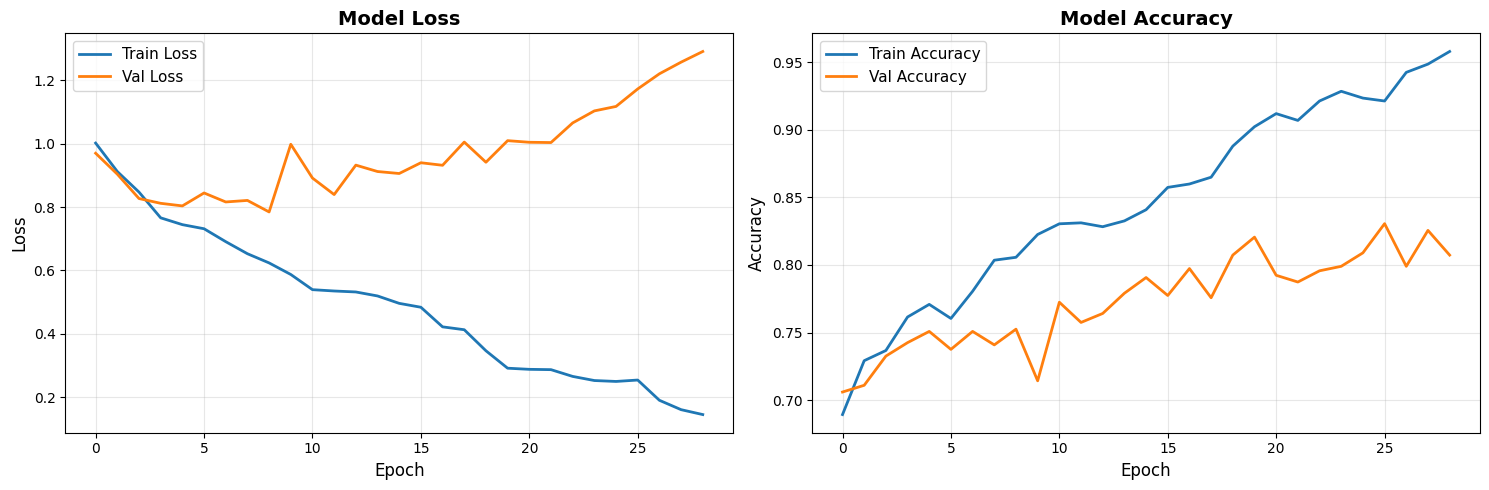


📊 Training Summary:
   Best Train Loss: 0.1458
   Best Val Loss:   0.7845
   Best Train Acc:  0.9580
   Best Val Acc:    0.8306


In [13]:
# ============================================================================
# BAGIAN 9: VISUALIZE TRAINING HISTORY (SAMA, TAPI ADA VAL METRICS!)
# ============================================================================

print("\n" + "="*70)
print("TRAINING HISTORY VISUALIZATION")
print("="*70)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history_stage2['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_stage2['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_stage2['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_stage2['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Print best metrics
print(f"\n📊 Training Summary:")
print(f"   Best Train Loss: {min(history_stage2['loss']):.4f}")
print(f"   Best Val Loss:   {min(history_stage2['val_loss']):.4f}")
print(f"   Best Train Acc:  {max(history_stage2['accuracy']):.4f}")
print(f"   Best Val Acc:    {max(history_stage2['val_accuracy']):.4f}")


In [14]:
"""
Script untuk verify model baru sudah benar
Jalankan ini untuk ensure model ready untuk deployment
"""

import os

print("="*70)
print("🔍 VERIFYING NEW MODEL: bayesian_densenet_FIXED.pth")
print("="*70)

MODEL_PATH = "models/bayesian_densenet_FIXED.pth"

# ============================================================================
# 1. CHECK FILE EXISTS & SIZE
# ============================================================================
print("\n1️⃣  Checking file...")

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ ERROR: Model not found at {MODEL_PATH}")

file_size = os.path.getsize(MODEL_PATH) / (1024 * 1024)  # MB
print(f"✅ Model found!")
print(f"   Size: {file_size:.2f} MB")

if file_size < 80:
    print(f"   ⚠️  WARNING: Size seems small. Expected: 80-200 MB")
elif file_size > 200:
    print(f"   ⚠️  WARNING: Size seems large. Expected: 80-200 MB")
else:
    print(f"   ✅ Size looks good!")

# ============================================================================
# 2. LOAD MODEL
# ============================================================================
print("\n2️⃣  Loading model...")

try:
    verify_model = BayesianDenseNet121(num_classes=5, dropout_rate=0.5, pretrained=False)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    verify_model.load_state_dict(state_dict)
    verify_model = verify_model.to(device)
    verify_model.eval()
    print("✅ Model loaded!")
except Exception as e:
    raise RuntimeError(f"❌ ERROR loading model: {e}")

# ============================================================================
# 3. CHECK ARCHITECTURE
# ============================================================================
print("\n3️⃣  Checking architecture...")

dummy_input = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    dummy_output = verify_model(dummy_input)

print(f"   Input shape:  {tuple(dummy_input.shape)}")
print(f"   Output shape: {tuple(dummy_output.shape)}")
print(f"   Total modules: {len(list(verify_model.modules()))}")

is_densenet = hasattr(verify_model, 'features')
print(f"   DenseNet-based: {'✅ Yes' if is_densenet else '❌ No'}")

dropout_layers = [name for name, m in verify_model.named_modules() if isinstance(m, nn.Dropout)]
print(f"   Dropout layers: {len(dropout_layers)} ({', '.join(dropout_layers)})")

if dummy_output.shape[-1] != 5:
    raise ValueError(f"   ❌ ERROR: Output should be 5 classes, found {dummy_output.shape[-1]}")
print(f"   ✅ Output classes: {dummy_output.shape[-1]}")


🔍 VERIFYING NEW MODEL: bayesian_densenet_FIXED.pth

1️⃣  Checking file...
✅ Model found!
   Size: 29.77 MB
   ⚠️  WARNING: Size seems small. Expected: 80-200 MB

2️⃣  Loading model...
✅ Model loaded!

3️⃣  Checking architecture...
   Input shape:  (1, 3, 224, 224)
   Output shape: (1, 5)
   Total modules: 442
   DenseNet-based: ✅ Yes
   Dropout layers: 3 (dropout_1, dropout_2, dropout_3)
   ✅ Output classes: 5


In [15]:
# ============================================================================
# 🔥 BAGIAN 11: BAYESIAN INFERENCE - PADA TEST SET! (PyTorch)
# ============================================================================

def enable_mc_dropout(model):
    """Set HANYA layer Dropout ke mode train (MC Dropout), sisanya (termasuk
    semua BatchNorm) tetap di mode eval — pengecekan pakai isinstance, lebih
    aman daripada mengandalkan substring 'dropout' pada nama layer seperti
    versi Keras."""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def bayesian_predict(model, data_loader, n_samples=50, device=device, verbose=True):
    """
    Perform Bayesian prediction using Monte Carlo Dropout.

    - Backbone + BatchNorm dijalankan SEKALI dalam mode eval (deterministik,
      BatchNorm pakai running stats — sama seperti versi Keras yang di-fix).
    - Hanya head Dense+Dropout yang di-sample n_samples kali dengan dropout
      aktif, dijalankan di atas fitur yang sudah di-cache (efisien, backbone
      tidak perlu dihitung ulang setiap sample).
    """

    print("\n" + "="*70)
    print(f"Performing Bayesian Inference with {n_samples} MC samples...")
    print("="*70)

    model.eval()  # backbone + BatchNorm dalam mode eval (deterministik)

    # ✅ STEP 1: Ekstrak fitur SEKALI (backbone + GAP + BN)
    all_features = []
    all_true_labels = []
    for images, labels in data_loader:
        images = images.to(device)
        features = model.forward_features(images)
        all_features.append(features)
        all_true_labels.append(labels.numpy())

    all_features = torch.cat(all_features, dim=0)          # (total_samples, num_features)
    true_classes = np.concatenate(all_true_labels, axis=0)  # (total_samples,)

    # ✅ STEP 2: Perform MC Dropout hanya pada head, n_samples kali
    enable_mc_dropout(model)

    N = all_features.size(0)
    infer_batch_size = 128
    all_predictions = []

    for sample_idx in range(n_samples):
        sample_probs = []
        for start in range(0, N, infer_batch_size):
            batch_feat = all_features[start:start + infer_batch_size]
            logits = model.forward_head(batch_feat)      # dropout aktif di sini
            probs = torch.softmax(logits, dim=1)
            sample_probs.append(probs.cpu().numpy())
        all_predictions.append(np.concatenate(sample_probs, axis=0))

        if verbose and (sample_idx + 1) % 10 == 0:
            print(f"Processed {sample_idx+1}/{n_samples} MC samples")

    all_predictions = np.array(all_predictions)  # Shape: (n_samples, total_samples, 5)

    # Compute statistics
    predictions_mean = np.mean(all_predictions, axis=0)  # Shape: (total_samples, 5)
    predictions_std = np.std(all_predictions, axis=0)    # Shape: (total_samples, 5)

    # Compute uncertainty metrics
    predictive_entropy = -np.sum(
        predictions_mean * np.log(predictions_mean + 1e-10),
        axis=1
    )

    expected_entropy = -np.mean(
        np.sum(all_predictions * np.log(all_predictions + 1e-10), axis=2),
        axis=0
    )

    mutual_information = predictive_entropy - expected_entropy

    # Get predictions
    pred_classes = np.argmax(predictions_mean, axis=1)
    confidences = np.max(predictions_mean, axis=1)

    print("\n✅ Bayesian inference completed!")
    print(f"   Total samples: {len(pred_classes)}")
    print(f"   Mean confidence: {np.mean(confidences):.2%}")
    print(f"   Mean uncertainty: {np.mean(predictions_std):.4f}")

    return {
        'predictions_mean': predictions_mean,
        'predictions_std': predictions_std,
        'all_predictions': all_predictions,
        'pred_classes': pred_classes,
        'true_classes': true_classes,
        'confidences': confidences,
        'predictive_entropy': predictive_entropy,
        'expected_entropy': expected_entropy,
        'mutual_information': mutual_information,
    }


# 🔥 KUNCI: Bayesian inference pada TEST SET (bukan validation!)
print("\n" + "="*70)
print("BAYESIAN INFERENCE ON TEST SET (FINAL EVALUATION)")
print("="*70)

model = BayesianDenseNet121(num_classes=5, dropout_rate=0.5, pretrained=False)
model.load_state_dict(torch.load('models/bayesian_densenet_FIXED.pth', map_location=device))
model = model.to(device)

# Verify model architecture
print("\n📋 Verifying model layers:")
print(f"   bn_1 layer: {model.bn_1}")
print(f"   dense_1 layer: {model.dense_1}")
print(f"   dropout_1 layer: {model.dropout_1}")

bayesian_results = bayesian_predict(
    model,
    test_loader,   # 🔥 GUNAKAN TEST SET!
    n_samples=50,
    verbose=True
)



BAYESIAN INFERENCE ON TEST SET (FINAL EVALUATION)

📋 Verifying model layers:
   bn_1 layer: BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   dense_1 layer: Linear(in_features=1024, out_features=512, bias=True)
   dropout_1 layer: Dropout(p=0.5, inplace=False)

Performing Bayesian Inference with 50 MC samples...
Processed 10/50 MC samples
Processed 20/50 MC samples
Processed 30/50 MC samples
Processed 40/50 MC samples
Processed 50/50 MC samples

✅ Bayesian inference completed!
   Total samples: 602
   Mean confidence: 78.48%
   Mean uncertainty: 0.0402


In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score

accuracy = accuracy_score(bayesian_results['true_classes'], bayesian_results['pred_classes'])
precision, recall, f1, _ = precision_recall_fscore_support(
    bayesian_results['true_classes'],
    bayesian_results['pred_classes'],
    average='weighted'
)
kappa = cohen_kappa_score(bayesian_results['true_classes'], bayesian_results['pred_classes'])

print(f"\n📊 TEST SET RESULTS:")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Kappa:     {kappa:.4f}")
print(f"{'='*50}")

# Prediction quality
print(f"\n🎯 PREDICTION QUALITY:")
print(f"Mean Confidence:  {np.mean(bayesian_results['confidences']):.4f}")
print(f"Mean Uncertainty: {np.mean(bayesian_results['predictive_entropy']):.4f}")

if np.mean(bayesian_results['confidences']) > 0.6:
    print(f"\n✅ EXCELLENT! Model is confident and decisive!")
elif np.mean(bayesian_results['confidences']) > 0.4:
    print(f"\n⚠️  GOOD. Model is somewhat confident.")
else:
    print(f"\n❌ POOR. Model still guessing.")


📊 TEST SET RESULTS:
Accuracy:  0.7857 (78.57%)
Precision: 0.8088
Recall:    0.7857
F1-Score:  0.7865
Kappa:     0.6940

🎯 PREDICTION QUALITY:
Mean Confidence:  0.7848
Mean Uncertainty: 0.5346

✅ EXCELLENT! Model is confident and decisive!



📊 DETAILED PER-CLASS EVALUATION METRICS

1. OVERALL MODEL PERFORMANCE

Metric                    Weighted        Macro          
-------------------------------------------------------
Accuracy                  0.7857 (78.57%)
Precision                 0.8088        0.6753
Recall                    0.7857        0.7078
F1-Score                  0.7865        0.6740
Cohen's Kappa             0.6940
-------------------------------------------------------

2. PER-CLASS PERFORMANCE METRICS

--------------------------------------------------------------------------------
Class           Support    Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
No_DR           277        0.9751 ( 97.5%)  0.9549 ( 95.5%)  0.9928 ( 99.3%)  0.9735 ( 97.3%)
Mild            60         0.9120 ( 91.2%)  0.5443 ( 54.4%)  0.7167 ( 71.7%)  0.6187 ( 61.9%)
Moderate        159        0.8555 ( 85.5%)  0.8214 ( 82.1%)  0.5786 ( 57.9%)  

/tmp/ipykernel_645/2828987364.py:341: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


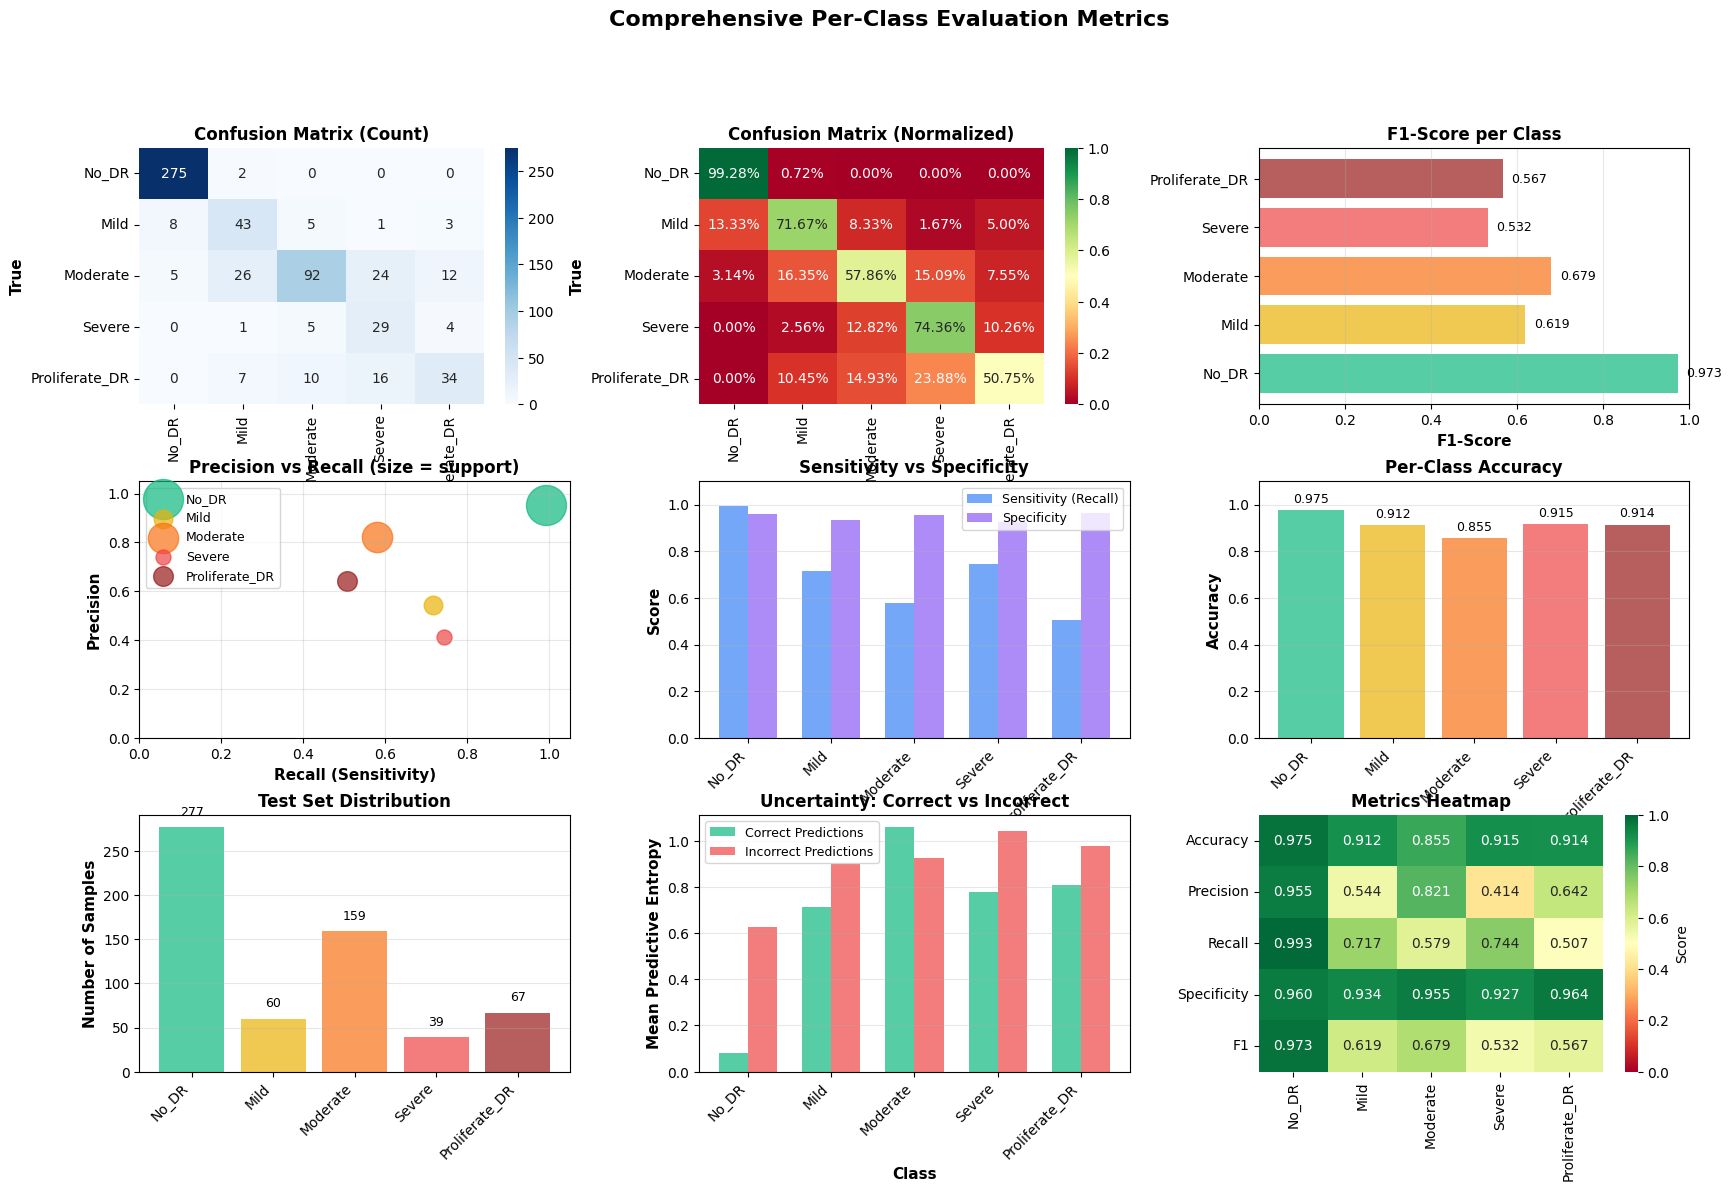

✅ Visualization saved: results/per_class_metrics_comprehensive.png

7. SAVING DETAILED METRICS TO CSV
✅ Saved: results/per_class_detailed_metrics.csv
✅ Saved: results/confusion_matrix.csv

8. MISCLASSIFICATION ANALYSIS

Top 10 Most Common Misclassifications:
----------------------------------------------------------------------
True Class      Predicted As    Count      Percentage  
----------------------------------------------------------------------
Moderate        Mild            26         16.35%
Moderate        Severe          24         15.09%
Proliferate_DR  Severe          16         23.88%
Moderate        Proliferate_DR  12         7.55%
Proliferate_DR  Moderate        10         14.93%
Mild            No_DR           8          13.33%
Proliferate_DR  Mild            7          10.45%
Mild            Moderate        5          8.33%
Severe          Moderate        5          12.82%
Moderate        No_DR           5          3.14%
----------------------------------------------

In [17]:
# ============================================================================
# 📊 PER-CLASS EVALUATION METRICS & VISUALIZATION
# ============================================================================
# Tambahkan bagian ini SETELAH Bayesian inference pada test set

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    cohen_kappa_score
)

print("\n" + "="*80)
print("📊 DETAILED PER-CLASS EVALUATION METRICS")
print("="*80)

# Class names
CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

# Get predictions and true labels from bayesian_results
y_true = bayesian_results['true_classes']
y_pred = bayesian_results['pred_classes']

# ============================================================================
# 1. OVERALL METRICS
# ============================================================================
print("\n" + "="*80)
print("1. OVERALL MODEL PERFORMANCE")
print("="*80)

overall_accuracy = accuracy_score(y_true, y_pred)
overall_kappa = cohen_kappa_score(y_true, y_pred)

# Calculate weighted metrics
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

# Calculate macro metrics
precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)

print(f"\n{'Metric':<25} {'Weighted':<15} {'Macro':<15}")
print("-" * 55)
print(f"{'Accuracy':<25} {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"{'Precision':<25} {precision_w:.4f}        {precision_m:.4f}")
print(f"{'Recall':<25} {recall_w:.4f}        {recall_m:.4f}")
print(f"{'F1-Score':<25} {f1_w:.4f}        {f1_m:.4f}")
print(f"{'Cohen\'s Kappa':<25} {overall_kappa:.4f}")
print("-" * 55)

# ============================================================================
# 2. PER-CLASS DETAILED METRICS
# ============================================================================
print("\n" + "="*80)
print("2. PER-CLASS PERFORMANCE METRICS")
print("="*80)

# Calculate per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(5), zero_division=0
)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(5))

# Calculate per-class accuracy, specificity, and other metrics
per_class_metrics = []

for i, class_name in enumerate(CLASS_NAMES):
    # True Positives, False Positives, False Negatives, True Negatives
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn

    # Calculate metrics
    class_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = recall[i]  # Same as recall

    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value (Precision)
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value

    per_class_metrics.append({
        'Class': class_name,
        'Support': int(support[i]),
        'Accuracy': class_accuracy,
        'Precision (PPV)': precision[i],
        'Recall (Sensitivity)': sensitivity,
        'Specificity': specificity,
        'F1-Score': f1[i],
        'NPV': npv,
        'TP': int(tp),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn)
    })

# Create DataFrame
metrics_df = pd.DataFrame(per_class_metrics)

# Print table
print("\n" + "-"*80)
print(f"{'Class':<15} {'Support':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*80)

for idx, row in metrics_df.iterrows():
    print(f"{row['Class']:<15} {row['Support']:<10} "
          f"{row['Accuracy']:.4f} ({row['Accuracy']*100:5.1f}%)  "
          f"{row['Precision (PPV)']:.4f} ({row['Precision (PPV)']*100:5.1f}%)  "
          f"{row['Recall (Sensitivity)']:.4f} ({row['Recall (Sensitivity)']*100:5.1f}%)  "
          f"{row['F1-Score']:.4f} ({row['F1-Score']*100:5.1f}%)")

print("-"*80)

# ============================================================================
# 3. CONFUSION MATRIX DETAILS PER CLASS
# ============================================================================
print("\n" + "="*80)
print("3. CONFUSION MATRIX BREAKDOWN (TP, TN, FP, FN)")
print("="*80)

print(f"\n{'Class':<15} {'TP':<8} {'TN':<8} {'FP':<8} {'FN':<8} {'Specificity':<12}")
print("-"*70)

for idx, row in metrics_df.iterrows():
    print(f"{row['Class']:<15} {row['TP']:<8} {row['TN']:<8} {row['FP']:<8} {row['FN']:<8} "
          f"{row['Specificity']:.4f} ({row['Specificity']*100:5.1f}%)")

print("-"*70)

# ============================================================================
# 4. CLASSIFICATION REPORT (Scikit-learn)
# ============================================================================
print("\n" + "="*80)
print("4. CLASSIFICATION REPORT (Scikit-learn)")
print("="*80)

print("\n" + classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

# ============================================================================
# 5. UNCERTAINTY ANALYSIS PER CLASS
# ============================================================================
print("\n" + "="*80)
print("5. UNCERTAINTY ANALYSIS PER CLASS")
print("="*80)

# Calculate mean uncertainty per class (for correct and incorrect predictions)
uncertainty_per_class = []

for i, class_name in enumerate(CLASS_NAMES):
    # Get samples of this class
    class_mask = y_true == i

    if class_mask.sum() == 0:
        continue

    # Correct and incorrect predictions for this class
    correct_mask = (y_true == i) & (y_pred == i)
    incorrect_mask = (y_true == i) & (y_pred != i)

    # Mean uncertainty
    mean_uncertainty_all = bayesian_results['predictive_entropy'][class_mask].mean()

    if correct_mask.sum() > 0:
        mean_uncertainty_correct = bayesian_results['predictive_entropy'][correct_mask].mean()
    else:
        mean_uncertainty_correct = 0

    if incorrect_mask.sum() > 0:
        mean_uncertainty_incorrect = bayesian_results['predictive_entropy'][incorrect_mask].mean()
    else:
        mean_uncertainty_incorrect = 0

    uncertainty_per_class.append({
        'Class': class_name,
        'Samples': int(class_mask.sum()),
        'Correct': int(correct_mask.sum()),
        'Incorrect': int(incorrect_mask.sum()),
        'Mean Uncertainty': mean_uncertainty_all,
        'Uncertainty (Correct)': mean_uncertainty_correct,
        'Uncertainty (Incorrect)': mean_uncertainty_incorrect,
        'Uncertainty Diff': mean_uncertainty_incorrect - mean_uncertainty_correct
    })

uncertainty_df = pd.DataFrame(uncertainty_per_class)

print(f"\n{'Class':<15} {'Samples':<10} {'Correct':<10} {'Incorrect':<10} {'Mean Unc.':<12} {'Unc. Diff':<12}")
print("-"*80)

for idx, row in uncertainty_df.iterrows():
    print(f"{row['Class']:<15} {row['Samples']:<10} {row['Correct']:<10} {row['Incorrect']:<10} "
          f"{row['Mean Uncertainty']:.4f}      {row['Uncertainty Diff']:+.4f}")

print("-"*80)
print("\n💡 Interpretation:")
print("   - Higher 'Uncertainty Diff' = Model is more uncertain on incorrect predictions (Good!)")
print("   - Lower 'Mean Uncertainty' = Model is more confident overall for this class")

# ============================================================================
# 6. VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("6. GENERATING VISUALIZATIONS")
print("="*80)

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 6.1 Confusion Matrix (Count)
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax1.set_ylabel('True', fontsize=11, fontweight='bold')
ax1.set_title('Confusion Matrix (Count)', fontsize=12, fontweight='bold')

# 6.2 Confusion Matrix (Normalized)
ax2 = fig.add_subplot(gs[0, 1])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax2, vmin=0, vmax=1)
ax2.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax2.set_ylabel('True', fontsize=11, fontweight='bold')
ax2.set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')

# 6.3 Per-Class F1-Score
ax3 = fig.add_subplot(gs[0, 2])
colors = ['#10b981', '#eab308', '#f97316', '#ef4444', '#991b1b']
bars = ax3.barh(CLASS_NAMES, metrics_df['F1-Score'], color=colors, alpha=0.7)
ax3.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax3.set_title('F1-Score per Class', fontsize=12, fontweight='bold')
ax3.set_xlim(0, 1)
ax3.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, metrics_df['F1-Score'])):
    ax3.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

# 6.4 Precision vs Recall
ax4 = fig.add_subplot(gs[1, 0])
for i, class_name in enumerate(CLASS_NAMES):
    ax4.scatter(metrics_df.iloc[i]['Recall (Sensitivity)'],
               metrics_df.iloc[i]['Precision (PPV)'],
               s=metrics_df.iloc[i]['Support']*3,
               color=colors[i],
               alpha=0.7,
               label=class_name)
ax4.set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Precision vs Recall (size = support)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 1.05)
ax4.set_ylim(0, 1.05)

# 6.5 Sensitivity vs Specificity
ax5 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(len(CLASS_NAMES))
width = 0.35
bars1 = ax5.bar(x_pos - width/2, metrics_df['Recall (Sensitivity)'],
                width, label='Sensitivity (Recall)', color='#3b82f6', alpha=0.7)
bars2 = ax5.bar(x_pos + width/2, metrics_df['Specificity'],
                width, label='Specificity', color='#8b5cf6', alpha=0.7)
ax5.set_xlabel('Class', fontsize=11, fontweight='bold')
ax5.set_ylabel('Score', fontsize=11, fontweight='bold')
ax5.set_title('Sensitivity vs Specificity', fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3)
ax5.set_ylim(0, 1.1)

# 6.6 Per-Class Accuracy
ax6 = fig.add_subplot(gs[1, 2])
bars = ax6.bar(CLASS_NAMES, metrics_df['Accuracy'], color=colors, alpha=0.7)
ax6.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax6.set_title('Per-Class Accuracy', fontsize=12, fontweight='bold')
ax6.set_ylim(0, 1.1)
ax6.grid(axis='y', alpha=0.3)
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, val in zip(bars, metrics_df['Accuracy']):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 6.7 Sample Distribution
ax7 = fig.add_subplot(gs[2, 0])
bars = ax7.bar(CLASS_NAMES, metrics_df['Support'], color=colors, alpha=0.7)
ax7.set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
ax7.set_title('Test Set Distribution', fontsize=12, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)
plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, val in zip(bars, metrics_df['Support']):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(val)}', ha='center', va='bottom', fontsize=9)

# 6.8 Uncertainty per Class
ax8 = fig.add_subplot(gs[2, 1])
x_pos = np.arange(len(CLASS_NAMES))
width = 0.35
bars1 = ax8.bar(x_pos - width/2, uncertainty_df['Uncertainty (Correct)'],
                width, label='Correct Predictions', color='#10b981', alpha=0.7)
bars2 = ax8.bar(x_pos + width/2, uncertainty_df['Uncertainty (Incorrect)'],
                width, label='Incorrect Predictions', color='#ef4444', alpha=0.7)
ax8.set_xlabel('Class', fontsize=11, fontweight='bold')
ax8.set_ylabel('Mean Predictive Entropy', fontsize=11, fontweight='bold')
ax8.set_title('Uncertainty: Correct vs Incorrect', fontsize=12, fontweight='bold')
ax8.set_xticks(x_pos)
ax8.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax8.legend(fontsize=9)
ax8.grid(axis='y', alpha=0.3)

# 6.9 Metrics Heatmap
ax9 = fig.add_subplot(gs[2, 2])
metrics_heatmap = metrics_df[['Accuracy', 'Precision (PPV)', 'Recall (Sensitivity)',
                               'Specificity', 'F1-Score']].values.T
sns.heatmap(metrics_heatmap, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=CLASS_NAMES,
            yticklabels=['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1'],
            ax=ax9, vmin=0, vmax=1, cbar_kws={'label': 'Score'})
ax9.set_title('Metrics Heatmap', fontsize=12, fontweight='bold')

plt.suptitle('Comprehensive Per-Class Evaluation Metrics',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('results/per_class_metrics_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: results/per_class_metrics_comprehensive.png")

# ============================================================================
# 7. SAVE DETAILED RESULTS TO CSV
# ============================================================================
print("\n" + "="*80)
print("7. SAVING DETAILED METRICS TO CSV")
print("="*80)

# Merge metrics and uncertainty DataFrames
detailed_results = pd.merge(metrics_df, uncertainty_df, on='Class')

# Save to CSV
detailed_results.to_csv('results/per_class_detailed_metrics.csv', index=False)
print("✅ Saved: results/per_class_detailed_metrics.csv")

# Also save confusion matrix
cm_df = pd.DataFrame(cm,
                     index=[f'True_{c}' for c in CLASS_NAMES],
                     columns=[f'Pred_{c}' for c in CLASS_NAMES])
cm_df.to_csv('results/confusion_matrix.csv')
print("✅ Saved: results/confusion_matrix.csv")

# ============================================================================
# 8. MISCLASSIFICATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("8. MISCLASSIFICATION ANALYSIS")
print("="*80)

# Find most common misclassifications
misclassifications = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm[i, j] > 0:
            misclassifications.append({
                'True Class': CLASS_NAMES[i],
                'Predicted As': CLASS_NAMES[j],
                'Count': int(cm[i, j]),
                'Percentage': cm[i, j] / cm[i, :].sum() * 100
            })

if misclassifications:
    misclass_df = pd.DataFrame(misclassifications)
    misclass_df = misclass_df.sort_values('Count', ascending=False)

    print("\nTop 10 Most Common Misclassifications:")
    print("-"*70)
    print(f"{'True Class':<15} {'Predicted As':<15} {'Count':<10} {'Percentage':<12}")
    print("-"*70)

    for idx, row in misclass_df.head(10).iterrows():
        print(f"{row['True Class']:<15} {row['Predicted As']:<15} "
              f"{row['Count']:<10} {row['Percentage']:.2f}%")

    print("-"*70)

    # Save to CSV
    misclass_df.to_csv('results/misclassifications.csv', index=False)
    print("\n✅ Saved: results/misclassifications.csv")
else:
    print("\n✅ Perfect classification! No misclassifications found.")

# ============================================================================
# 9. SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("9. SUMMARY STATISTICS")
print("="*80)

summary = {
    'Total Samples': len(y_true),
    'Correctly Classified': int((y_true == y_pred).sum()),
    'Misclassified': int((y_true != y_pred).sum()),
    'Overall Accuracy': f"{overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)",
    'Weighted Precision': f"{precision_w:.4f}",
    'Weighted Recall': f"{recall_w:.4f}",
    'Weighted F1-Score': f"{f1_w:.4f}",
    'Macro Precision': f"{precision_m:.4f}",
    'Macro Recall': f"{recall_m:.4f}",
    'Macro F1-Score': f"{f1_m:.4f}",
    'Cohen\'s Kappa': f"{overall_kappa:.4f}",
    'Best Performing Class': CLASS_NAMES[metrics_df['F1-Score'].idxmax()],
    'Worst Performing Class': CLASS_NAMES[metrics_df['F1-Score'].idxmin()],
    'Most Uncertain Class': CLASS_NAMES[uncertainty_df['Mean Uncertainty'].idxmax()],
    'Least Uncertain Class': CLASS_NAMES[uncertainty_df['Mean Uncertainty'].idxmin()]
}

print("\n📊 Model Performance Summary:")
print("-"*70)
for key, value in summary.items():
    print(f"{key:<30} : {value}")
print("-"*70)

# Save summary
import json
with open('results/evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\n✅ Saved: results/evaluation_summary.json")

print("\n" + "="*80)
print("✅ PER-CLASS EVALUATION COMPLETE!")
print("="*80)
print("\nGenerated Files:")
print("   1. results/per_class_metrics_comprehensive.png")
print("   2. results/per_class_detailed_metrics.csv")
print("   3. results/confusion_matrix.csv")
print("   4. results/misclassifications.csv")
print("   5. results/evaluation_summary.json")
print("="*80)